In [ ]:
import pandas as pd
import os

DATA_PATH = '../../data/alpha vantage/'

# Load the Alpha Vantage data
BIL   = pd.read_csv(os.path.join(DATA_PATH, "BIL.csv"), parse_dates=["timestamp"])
BND   = pd.read_csv(os.path.join(DATA_PATH, "BND.csv"), parse_dates=["timestamp"])
EFA   = pd.read_csv(os.path.join(DATA_PATH, "EFA.csv"), parse_dates=["timestamp"])
RWR   = pd.read_csv(os.path.join(DATA_PATH, "RWR.csv"), parse_dates=["timestamp"])
SPY   = pd.read_csv(os.path.join(DATA_PATH, "SPY.csv"), parse_dates=["timestamp"])
VBMFX = pd.read_csv(os.path.join(DATA_PATH, "VBMFX.csv"), parse_dates=["timestamp"])
VNQ   = pd.read_csv(os.path.join(DATA_PATH, "VNQ.csv"), parse_dates=["timestamp"])
VTI   = pd.read_csv(os.path.join(DATA_PATH, "VTI.csv"), parse_dates=["timestamp"])
VXUS  = pd.read_csv(os.path.join(DATA_PATH, "VXUS.csv"), parse_dates=["timestamp"])

# ============== Loading other data sources ==============
# From Federal Reserve Bank of St. Louis, https://fred.stlouisfed.org/series/DTB3
DTB3 = pd.read_csv(os.path.join(DATA_PATH, "../used", "DTB3.csv"), parse_dates=["observation_date"])
DTB3.rename(columns={"observation_date": "Date"}, inplace=True)

for df in [BIL, BND, EFA, RWR, SPY, VBMFX, VNQ, VTI, VXUS]:
  df.rename(columns={'timestamp': 'Date'}, inplace=True)

BIL.set_index("Date", inplace=True)
BND.set_index("Date", inplace=True)
DTB3.set_index("Date", inplace=True)
EFA.set_index("Date", inplace=True)
RWR.set_index("Date", inplace=True)
SPY.set_index("Date", inplace=True)
VBMFX.set_index("Date", inplace=True)
VNQ.set_index("Date", inplace=True)
VTI.set_index("Date", inplace=True)
VXUS.set_index("Date", inplace=True)

This data set looks much more promising than the Kaggle dataset, the shortest time series has 3806 data points.

In [7]:
print(f"Total NA in BIL  : {BIL.isna().sum()}")
print(f"Total NA in BND  : {BND.isna().sum()}")
print(f"Total NA in DTB3 : {DTB3.isna().sum()}")
print(f"Total NA in EFA  : {EFA.isna().sum()}")
print(f"Total NA in RWR  : {RWR.isna().sum()}")
print(f"Total NA in SPY  : {SPY.isna().sum()}")
print(f"Total NA in VBMFX: {VBMFX.isna().sum()}")
print(f"Total NA in VNQ  : {VNQ.isna().sum()}")
print(f"Total NA in VTI  : {VTI.isna().sum()}")
print(f"Total NA in VXUS : {VXUS.isna().sum()}")

Total NA in BIL  : open                 0
high                 0
low                  0
close                0
adjusted_close       0
volume               0
dividend_amount      0
split_coefficient    0
dtype: int64
Total NA in BND  : open                 0
high                 0
low                  0
close                0
adjusted_close       0
volume               0
dividend_amount      0
split_coefficient    0
dtype: int64
Total NA in DTB3 : DTB3    795
dtype: int64
Total NA in EFA  : open                 0
high                 0
low                  0
close                0
adjusted_close       0
volume               0
dividend_amount      0
split_coefficient    0
dtype: int64
Total NA in RWR  : open                 0
high                 0
low                  0
close                0
adjusted_close       0
volume               0
dividend_amount      0
split_coefficient    0
dtype: int64
Total NA in SPY  : open                 0
high                 0
low                  0
clos

In [16]:
# Print days with NA values
print(DTB3[DTB3['DTB3'].isna()].index)

DatetimeIndex(['1954-01-19', '1954-02-12', '1954-02-22', '1954-05-31',
               '1954-07-05', '1954-09-06', '1954-10-12', '1954-11-02',
               '1954-11-11', '1954-11-25',
               ...
               '2025-05-26', '2025-06-19', '2025-07-04', '2025-09-01',
               '2025-10-13', '2025-11-11', '2025-11-27', '2025-12-25',
               '2026-01-01', '2026-01-19'],
              dtype='datetime64[us]', name='Date', length=795, freq=None)


The only missing data we have is `DTB3`, which remains unchanged from the original data set.

In [17]:
# Kaggle dataset used adjusted close on the back end, so this should align.
close_vals =  [
                BIL['adjusted_close']  , BND['adjusted_close'],
                DTB3["DTB3"]           , EFA['adjusted_close'],
                RWR['adjusted_close']  , SPY['adjusted_close'],
                VBMFX['adjusted_close'], VNQ['adjusted_close'],
                VTI['adjusted_close']  , VXUS['adjusted_close'],
              ]

col_names = ["BIL", "BND", "DTB3", "EFA", "RWR", "SPY", "VBMFX", "VNQ", "VTI", "VXUS"]
combined = pd.concat(close_vals, axis=1)
combined.columns = col_names

combined.sort_index(inplace=True)

print(combined.shape)
cleaned = combined.dropna(how="any")  # Find the max period where no feature has an NA
print(cleaned.shape)

cleaned[col_names] = cleaned[col_names].apply(pd.to_numeric)

print(cleaned.isna().sum())

(18837, 10)
(3750, 10)
BIL      0
BND      0
DTB3     0
EFA      0
RWR      0
SPY      0
VBMFX    0
VNQ      0
VTI      0
VXUS     0
dtype: int64


C:\Users\drewm\AppData\Local\Temp\ipykernel_3124\3263001673.py:11: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat(close_vals, axis=1)


The new joined, cleaned data set is 3750 data points in length, totalling nearly 15 years (252 trading days per year).

Plotting BIL, mean: 5.373456831506513e-05
Plotting BND, mean: 9.905896751048697e-05
Plotting EFA, mean: 0.000327410188934687
Plotting RWR, mean: 0.00036153224376821267
Plotting SPY, mean: 0.0005758319415213358
Plotting VBMFX, mean: 9.335049273551596e-05
Plotting VNQ, mean: 0.00036405619701277895
Plotting VTI, mean: 0.0005649376732356411
Plotting VXUS, mean: 0.00031012174745498566
Plotting DTB3, mean: 5.906497354497355e-05


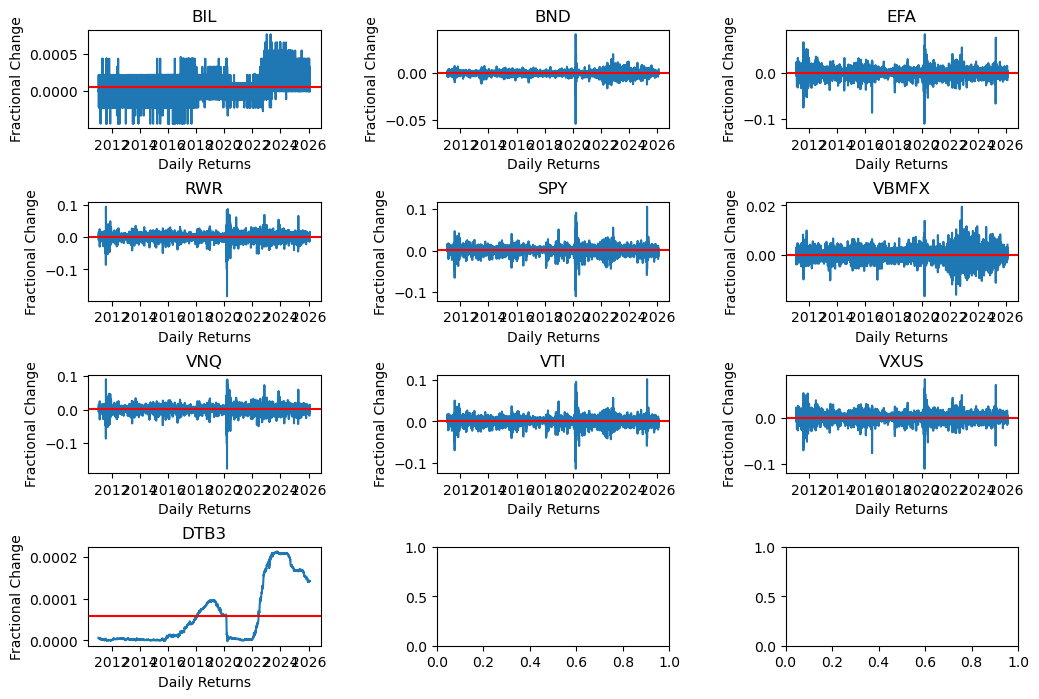

In [18]:
import matplotlib.pyplot as plt

tckrs = cleaned.loc[:, cleaned.columns != "DTB3"]

ret = tckrs.pct_change()

dtb3_daily = (cleaned["DTB3"] / 100) / 252
ret = ret.join(dtb3_daily.rename("DTB3"))

fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(12, 8))
fig.subplots_adjust(hspace=.75, wspace=0.5)

means = []
for idx, col in enumerate(list(ret.columns)):
  mean = ret[col].mean()
  means.append(mean)

  print(f"Plotting {col}, mean: {mean}")

  i = idx // 3
  j = idx % 3

  ax[i, j].plot(ret.index, ret[col])

  ax[i, j].axhline(mean, color="red")

  ax[i, j].set(xlabel='Daily Returns', ylabel='Fractional Change',
         title=str(col))

The longer view of this data set provides a significantly more nuanced data set, which can be seen most obvious in the effect of COVID-19 on DTB3, but also on other assets such as VBMFX. Every asset shares a massive spike in variance at the start of COVID.

In [19]:
summary = pd.DataFrame({
    "mean": ret.mean(),
    "std": ret.std(),
    "skew": ret.skew(),
    "kurtosis": ret.kurtosis(),
    "min": ret.min(),
    "max": ret.max()
})

summary.sort_values("std", ascending=False)
print(summary)

           mean       std      skew   kurtosis       min       max
BIL    0.000054  0.000166  0.257845   0.929914 -0.000438  0.000765
BND    0.000099  0.003087 -0.935915  39.251770 -0.054385  0.042201
EFA    0.000327  0.011322 -0.707885  10.371234 -0.109902  0.084731
RWR    0.000362  0.013045 -0.959690  18.160363 -0.183107  0.094360
SPY    0.000576  0.010841 -0.349118  12.832888 -0.109424  0.105019
VBMFX  0.000093  0.002860 -0.108420   3.009267 -0.016770  0.019502
VNQ    0.000364  0.012602 -0.883389  17.933902 -0.177277  0.091039
VTI    0.000565  0.011081 -0.384313  12.787900 -0.113809  0.101456
VXUS   0.000310  0.011119 -0.758098  10.486366 -0.111319  0.083810
DTB3   0.000059  0.000073  0.980382  -0.579949 -0.000002  0.000213


It is preferable that we retain a minimal kurtosis, because a smaller kurtosis effectively lowers the inherent risk of a markowitz model. Due to the effect of COVID and other more modern economic contexts, we see significantly amplified kurtosis when viewing the whole data set. It may be worth gathering the kurtosis information for the lookback period a user selects, so we can display a 'model trust' parameter. High kurtosis means large tails, which implies that extreme events are more common, thus a markowitz model relying on stable markets may fail.

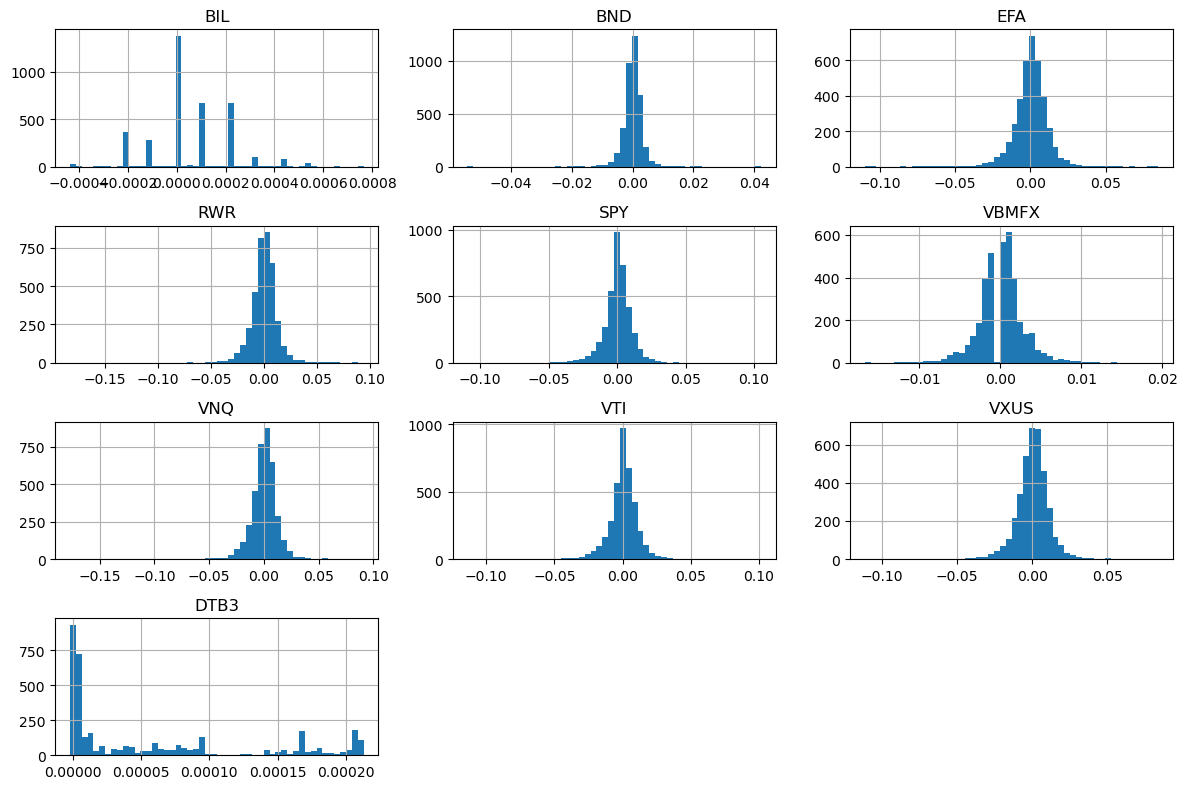

In [20]:
ret.hist(bins=50, figsize=(12, 8))
plt.tight_layout()

BIL is still largely a normal distribution, but displays the larger tails that the amplified kurtosis implies. With additional data points, each distribution initially appears to reflect a sharper, smaller tailed distribution. However, comparing these plots to the original data the x-axis is amplified 2-3 times for our new plots to fit a small number of data points, capturing rare and extreme events.

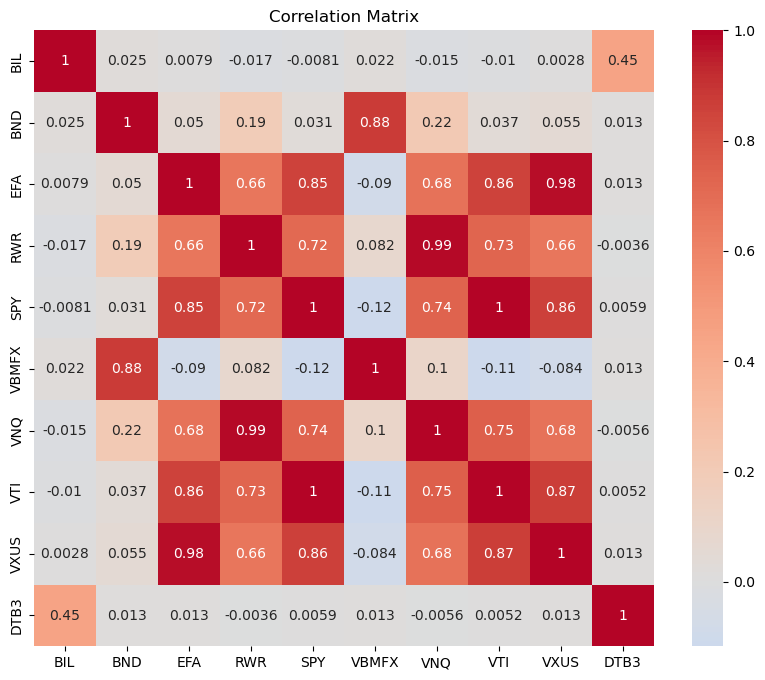

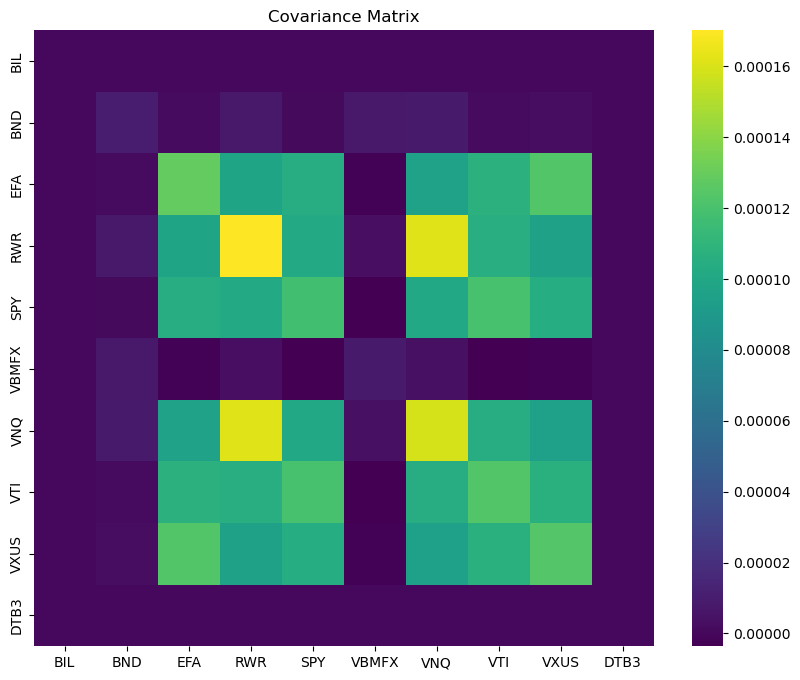

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = ret.corr() # Get correlation matrix
cov = ret.cov() # Get covariance matrix


plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(cov, cmap="viridis")
plt.title("Covariance Matrix")
plt.show()

These results are not especially promising in comparison to the original data set, it appears that, over the full period, the assets all have stronger, positive or near-positive correlations with each other. My model enforces a long-only portfolio (shorting is risky), so this limits what my model is able to optimize. This may not be a problem over a shorter lookback, but it's worth keeping in mind.

Eigenvalues:
[1.08761309e-08 7.52025655e-06 1.60107367e-05 5.23819032e-05
 3.39940196e-04]
Min eigenvalue: 1.08761309110017e-08
Max eigenvalue: 0.0003399401955440464
Condition number: 31255.618227266965


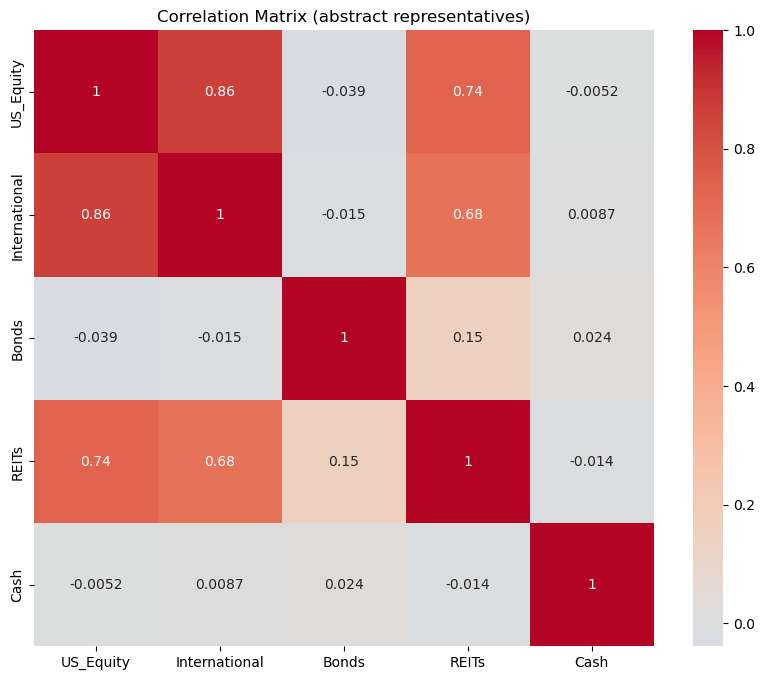

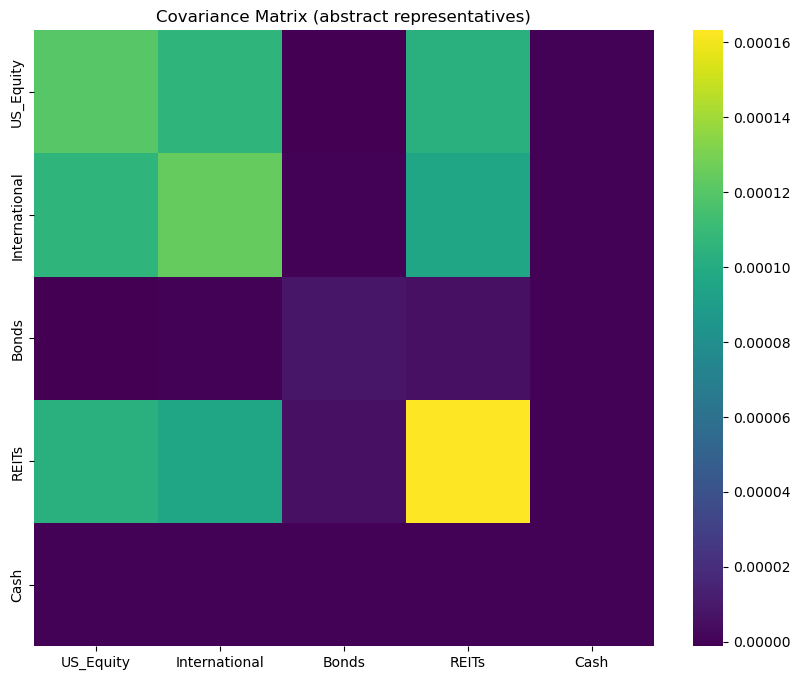

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Derive the average from each of the 2 stocks selected for each asset class.
us_equity = ret[["SPY", "VTI"]].mean(axis=1)
intl_equity = ret[["EFA", "VXUS"]].mean(axis=1)
bonds = ret[["BND", "VBMFX"]].mean(axis=1)
reits = ret[["VNQ", "RWR"]].mean(axis=1)
cash = ret[["BIL", "DTB3"]].mean(axis=1)

# Returns of the 5 'asset-class' representatives we've derived
ret5 = pd.concat([
    us_equity.rename("US_Equity"),
    intl_equity.rename("International"),
    bonds.rename("Bonds"),
    reits.rename("REITs"),
    cash.rename("Cash")
], axis=1)

corr5 = ret5.corr()
cov5 = ret5.cov()
eigs = np.linalg.eigvalsh(cov5) #eigvalsh (not eigvals) because cov is symmetric

print("Eigenvalues:")
print(eigs)

print("Min eigenvalue:", eigs.min())
print("Max eigenvalue:", eigs.max())
print("Condition number:", eigs.max() / eigs.min())

plt.figure(figsize=(10, 8))
sns.heatmap(corr5, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (abstract representatives)")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(cov5, cmap="viridis")
plt.title("Covariance Matrix (abstract representatives)")
plt.show()

The results from the abstracted classes reflect a similar relationship to the original data set, but with weaker negative and stronger positive correlations, as seen with the raw asset data. Bonds and cash remain as our only method for balancing higher risk equities, and the lookback period will become a crucial element to consider.

In [23]:
ret5.to_csv("daily_returns.csv")
cleaned.to_csv("cleaned.csv")